In [1]:
from typing import TypedDict, List
from langgraph.graph import StateGraph, START, END

In [2]:
class AgentState(TypedDict):
    play_name: str
    target: int
    guesses: List[int]
    attempts: int
    lower_bound: int
    upper_bound: int

In [3]:
graph = StateGraph(AgentState)

In [4]:
def setup_action(state: AgentState) -> AgentState:
    """
    innitialize the state
    :param state:
    :return: state
    """
    state["guesses"] = []
    state["attempts"] = 0
    state["lower_bound"] = 0
    state["upper_bound"] = 20
    return state

import random
def guess_action(state: AgentState) -> AgentState:
    """ guess the next value """
    state["attempts"] += 1
    state["guesses"].append(random.randint(state["lower_bound"], state["upper_bound"]))
    return state

def tooltip_action(state: AgentState) -> AgentState:
    """give player a tooltip"""
    print(f"guessing {state['guesses'][-1]} \n")
    if state["guesses"][-1] == state["target"]:
        return state
    elif state["guesses"][-1] > state["target"]:
        state["upper_bound"] = state["guesses"][-1]
        print("bigger than target \n")
        print(f"current state {state} \n")
        return state
    else:
        state["lower_bound"] = state["guesses"][-1]
        print("smaller than target \n")
        print(f"current state {state} \n")
        return state

graph.add_node("setup_node",setup_action)
graph.add_node("guess_node",guess_action)
graph.add_node("tooltip_node",tooltip_action)

## add edges
graph.add_edge(START, "setup_node")
graph.add_edge("setup_node", "guess_node")
graph.add_edge("guess_node", "tooltip_node")

def tooltip_decesion(state: AgentState):
    """ decesion keep guessing or end"""
    if state["guesses"][-1] == state["target"] or state["attempts"] >= 7 :
        print("stop guessing \n")
        return "exit"
    else :
        print("keep on guessing \n")
        return "guess_edges"

graph.add_conditional_edges(
    "tooltip_node",
    tooltip_decesion,
    {
        "guess_edges": "guess_node",
        "exit":END
    }
)
app = graph.compile()

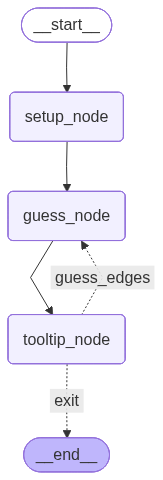

In [5]:
from IPython.display import display, Image
display(Image(app.get_graph().draw_mermaid_png()))

In [6]:
print(app.invoke(AgentState(play_name="zlp", target=7)))

guessing 1 

smaller than target 

current state {'play_name': 'zlp', 'target': 7, 'guesses': [1], 'attempts': 1, 'lower_bound': 1, 'upper_bound': 20} 

keep on guessing 

guessing 9 

bigger than target 

current state {'play_name': 'zlp', 'target': 7, 'guesses': [1, 9], 'attempts': 2, 'lower_bound': 1, 'upper_bound': 9} 

keep on guessing 

guessing 6 

smaller than target 

current state {'play_name': 'zlp', 'target': 7, 'guesses': [1, 9, 6], 'attempts': 3, 'lower_bound': 6, 'upper_bound': 9} 

keep on guessing 

guessing 8 

bigger than target 

current state {'play_name': 'zlp', 'target': 7, 'guesses': [1, 9, 6, 8], 'attempts': 4, 'lower_bound': 6, 'upper_bound': 8} 

keep on guessing 

guessing 6 

smaller than target 

current state {'play_name': 'zlp', 'target': 7, 'guesses': [1, 9, 6, 8, 6], 'attempts': 5, 'lower_bound': 6, 'upper_bound': 8} 

keep on guessing 

guessing 8 

bigger than target 

current state {'play_name': 'zlp', 'target': 7, 'guesses': [1, 9, 6, 8, 6, 8], 'at